# 3. Возможности Python по решению задачи линейной регрессии

Продемонстрируйте свое умение решать обе рассмотренные задачи с помощью методов fit и predict из sklearn.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv('data/ex1data2.txt', names=['size', 'bedrooms', 'price'])
data.head()

,size,bedrooms,price
0,2104,3,399900
1,1600,3,329900
2,2400,3,369000
3,1416,2,232000
4,3000,4,539900


In [2]:
data.describe()

,size,bedrooms,price
count,47.000000,47.000000,47.000000
mean,2000.680851,3.170213,340412.659574
std,794.702354,0.760982,125039.899586
min,852.000000,1.000000,169900.000000
25%,1432.000000,3.000000,249900.000000
50%,1888.000000,3.000000,299900.000000
75%,2269.000000,4.000000,384450.000000
max,4478.000000,5.000000,699900.000000


In [3]:
data[['size', 'bedrooms', 'price']] = data[['size', 'bedrooms', 'price']].apply(lambda x: (x - x.mean()) / x.std())
data.head()

,size,bedrooms,price
0,0.130010,-0.223675,0.475747
1,-0.504190,-0.223675,-0.084074
2,0.502476,-0.223675,0.228626
3,-0.735723,-1.537767,-0.867025
4,1.257476,1.090417,1.595389


In [4]:
data.describe()

,size,bedrooms,price
count,4.700000e+01,4.700000e+01,4.700000e+01
mean,3.779483e-17,2.746030e-16,-9.684924e-17
std,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.445423e+00,-2.851859e+00,-1.363666e+00
25%,-7.155897e-01,-2.236752e-01,-7.238702e-01
50%,-1.417900e-01,-2.236752e-01,-3.239979e-01
75%,3.376348e-01,1.090417e+00,3.521863e-01
max,3.117292e+00,2.404508e+00,2.874981e+00


In [5]:
# noinspection PyShadowingNames
def computeCost(X: np.matrix, y: np.matrix, theta: np.matrix) -> float:
    y = y.reshape(-1, 1)
    theta = theta.reshape(-1, 1)
    j = X @ theta - y
    return (j.T @ j).item() / (2 * len(y))

In [6]:
from typing import Tuple, List


# noinspection PyShadowingNames
def gradientDescent(X: np.matrix, y: np.matrix, theta: np.matrix, alpha: float, iters: int) -> Tuple[
    np.matrix, List[float]]:
    iters_history: List[float] = list()
    y = y.reshape(-1, 1)
    theta = theta.reshape(-1, 1)
    for i in range(iters):
        theta = theta - (alpha / len(y)) * X.T @ (X @ theta - y)
        iters_history.append(computeCost(X=X, y=y, theta=theta))
    return theta, iters_history

In [7]:
# noinspection PyTypeChecker, PyShadowingNames
def predict(X: np.matrix, theta: np.matrix) -> np.matrix:
    return X @ theta

In [8]:
X = np.column_stack([np.ones(len(data)), data.iloc[:, :-1]])
y = data['price'].values
theta = np.zeros((3, 1))
alpha: float = 0.05
iters: int = 1000
new_theta, iters_history = gradientDescent(X=X, y=y, theta=theta, alpha=alpha, iters=iters)
print(f'new_theta =\n {new_theta}')
print(f'J(new_theta) = {iters_history[-1]}')

new_theta =
 [[-1.10669937e-16]
 [ 8.84765988e-01]
 [-5.31788195e-02]]
J(new_theta) = 0.130686480539042


In [9]:
from sklearn import linear_model

model = linear_model.LinearRegression()
model.fit(X=X, y=y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Text(0, 0.5, 'Predicted')

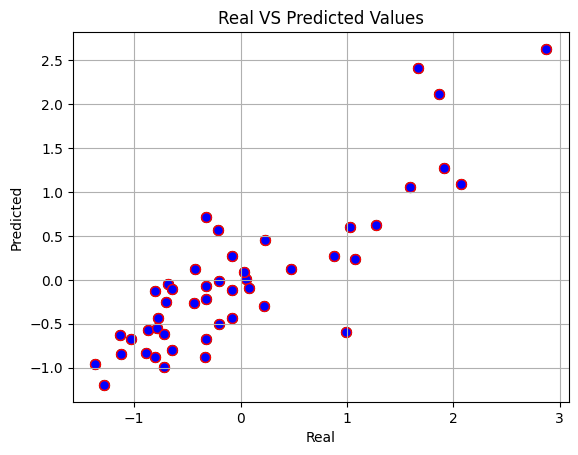

In [10]:
# Визуализация результата работы многомерной линейной регрессии: scatter plot
plt.scatter(y, predict(X=X, theta=new_theta), color='blue', marker='o', edgecolor='black', s=50)
plt.scatter(y, model.predict(X), color='blue', marker='o', edgecolor='red', s=50)
plt.grid(True)
plt.title("Real VS Predicted Values")
plt.xlabel('Real')
plt.ylabel('Predicted')